# 02 — Modeling & Evaluation: CICIDS2017 Network Intrusion Detection

This notebook trains and evaluates classifiers on the cleaned CICIDS2017
dataset produced by `01_eda_and_preprocessing.ipynb`, for two tasks:

1. **Binary classification** — `BENIGN` vs `ATTACK`
2. **Multiclass classification** — identify the specific attack category

For each task we compare a linear baseline (Logistic Regression) against
two tree-based ensembles (Random Forest, XGBoost), and evaluate using
metrics appropriate for an imbalanced classification problem: per-class
precision/recall/F1, macro-F1, confusion matrices, and ROC-AUC (binary).

We deliberately avoid relying on raw accuracy as the headline metric —
with ~80% of traffic being benign, a model that predicts "BENIGN" for
everything would already score ~80% accuracy while being useless.


In [1]:
import sys
sys.path.insert(0, "../src")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from preprocessing import split_and_scale
from evaluation import (
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
    summarize_results,
)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
df = pd.read_parquet("../data/processed/cicids2017_clean.parquet")
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
df[["label_binary", "label_multiclass"]].nunique()


Loaded 2,520,798 rows x 72 columns


label_binary         2
label_multiclass    13
dtype: int64

---
# Part A — Binary Classification (BENIGN vs ATTACK)


In [3]:
prep = split_and_scale(df, target="label_binary")
print(f"Train: {prep.X_train.shape}, Test: {prep.X_test.shape}")
print(f"Train class balance:\n{prep.y_train.value_counts(normalize=True)}")


Train: (2016638, 69), Test: (504160, 69)
Train class balance:
label_binary
BENIGN    0.831109
ATTACK    0.168891
Name: proportion, dtype: float64


## A.1 — Logistic Regression (baseline)

A linear model gives us a floor: if tree-based models can't beat this by
much, the extra complexity isn't earning its keep. We use
`class_weight="balanced"` to account for the BENIGN/ATTACK imbalance.


In [4]:
results = {}

t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(prep.X_train, prep.y_train)
lr_pred = lr.predict(prep.X_test)
lr_time = time.time() - t0

print_classification_report(prep.y_test, lr_pred, labels=prep.label_classes,
                              title="Logistic Regression — Binary")

lr_proba = lr.predict_proba(prep.X_test)[:, list(lr.classes_).index("ATTACK")]
results["Logistic Regression"] = {
    "accuracy": accuracy_score(prep.y_test, lr_pred),
    "macro_f1": f1_score(prep.y_test, lr_pred, average="macro"),
    "roc_auc": roc_auc_score((prep.y_test == "ATTACK").astype(int), lr_proba),
    "train_time_s": lr_time,
}


=== Logistic Regression — Binary ===
              precision    recall  f1-score   support

      ATTACK      0.747     0.977     0.846     85148
      BENIGN      0.995     0.933     0.963    419012

    accuracy                          0.940    504160
   macro avg      0.871     0.955     0.905    504160
weighted avg      0.953     0.940     0.943    504160



## A.2 — Random Forest

Tree-based ensembles typically dominate on this dataset because attack
flows tend to occupy distinct regions of feature space (e.g. PortScan
flows have near-zero payload; DoS Hulk flows have extreme packet rates) —
exactly the kind of axis-aligned splits trees excel at.


In [5]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, n_jobs=-1,
    class_weight="balanced", random_state=RANDOM_STATE
)
rf.fit(prep.X_train, prep.y_train)
rf_pred = rf.predict(prep.X_test)
rf_time = time.time() - t0

print_classification_report(prep.y_test, rf_pred, labels=prep.label_classes,
                              title="Random Forest — Binary")

rf_proba = rf.predict_proba(prep.X_test)[:, list(rf.classes_).index("ATTACK")]
results["Random Forest"] = {
    "accuracy": accuracy_score(prep.y_test, rf_pred),
    "macro_f1": f1_score(prep.y_test, rf_pred, average="macro"),
    "roc_auc": roc_auc_score((prep.y_test == "ATTACK").astype(int), rf_proba),
    "train_time_s": rf_time,
}


=== Random Forest — Binary ===
              precision    recall  f1-score   support

      ATTACK      0.995     0.999     0.997     85148
      BENIGN      1.000     0.999     0.999    419012

    accuracy                          0.999    504160
   macro avg      0.997     0.999     0.998    504160
weighted avg      0.999     0.999     0.999    504160



## A.3 — XGBoost

In [6]:
le = LabelEncoder()
y_train_enc = le.fit_transform(prep.y_train)
y_test_enc = le.transform(prep.y_test)
attack_idx = list(le.classes_).index("ATTACK")

# scale_pos_weight to address class imbalance
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = neg / pos

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(prep.X_train, y_train_enc)
xgb_pred = xgb.predict(prep.X_test)
xgb_time = time.time() - t0

print_classification_report(y_test_enc, xgb_pred, labels=list(range(len(le.classes_))),
                              title="XGBoost — Binary")
print("Label mapping:", dict(enumerate(le.classes_)))

xgb_proba = xgb.predict_proba(prep.X_test)[:, attack_idx]
results["XGBoost"] = {
    "accuracy": accuracy_score(y_test_enc, xgb_pred),
    "macro_f1": f1_score(y_test_enc, xgb_pred, average="macro"),
    "roc_auc": roc_auc_score((y_test_enc == attack_idx).astype(int), xgb_proba),
    "train_time_s": xgb_time,
}


=== XGBoost — Binary ===
              precision    recall  f1-score   support

           0      0.994     1.000     0.997     85148
           1      1.000     0.999     0.999    419012

    accuracy                          0.999    504160
   macro avg      0.997     0.999     0.998    504160
weighted avg      0.999     0.999     0.999    504160

Label mapping: {0: 'ATTACK', 1: 'BENIGN'}


## A.4 — Model comparison

In [7]:
comparison = summarize_results(results)
comparison


,accuracy,macro_f1,roc_auc,train_time_s
Logistic Regression,0.940110,0.904574,0.987947,125.013088
Random Forest,0.998947,0.998127,0.999948,282.535338
XGBoost,0.999012,0.998244,0.999971,26.451682


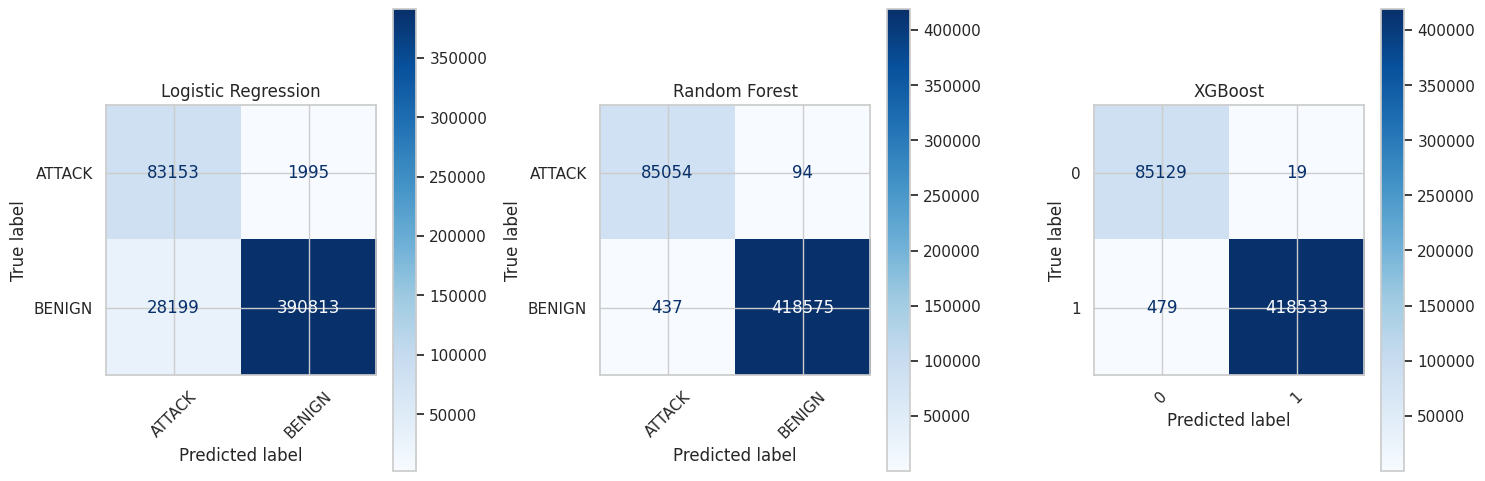

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_confusion_matrix(prep.y_test, lr_pred, labels=prep.label_classes,
                       title="Logistic Regression", ax=axes[0])
plot_confusion_matrix(prep.y_test, rf_pred, labels=prep.label_classes,
                       title="Random Forest", ax=axes[1])
plot_confusion_matrix(y_test_enc, xgb_pred, labels=list(range(len(le.classes_))),
                       title="XGBoost", ax=axes[2])
plt.tight_layout()
plt.savefig("../outputs/figures/05_binary_confusion_matrices.png", dpi=150)
plt.show()


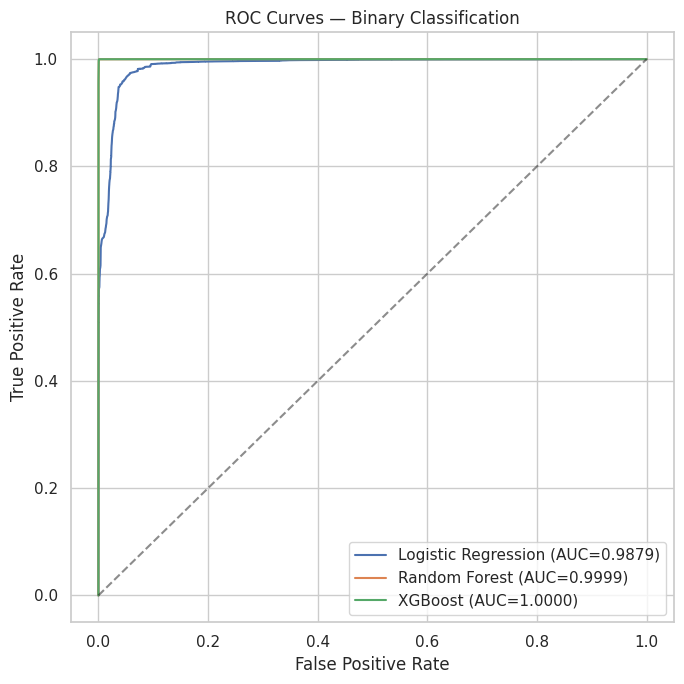

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, proba, true_vals, pos_lab in [
    ("Logistic Regression", lr_proba, prep.y_test, "ATTACK"),
    ("Random Forest", rf_proba, prep.y_test, "ATTACK"),
    ("XGBoost", xgb_proba, y_test_enc, attack_idx),
]:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve((np.array(true_vals) == pos_lab).astype(int), proba)
    auc = results[name]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Binary Classification")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/06_roc_curves.png", dpi=150)
plt.show()


## A.5 — Feature importance (Random Forest)

Which flow-level features drive the binary attack/benign decision?


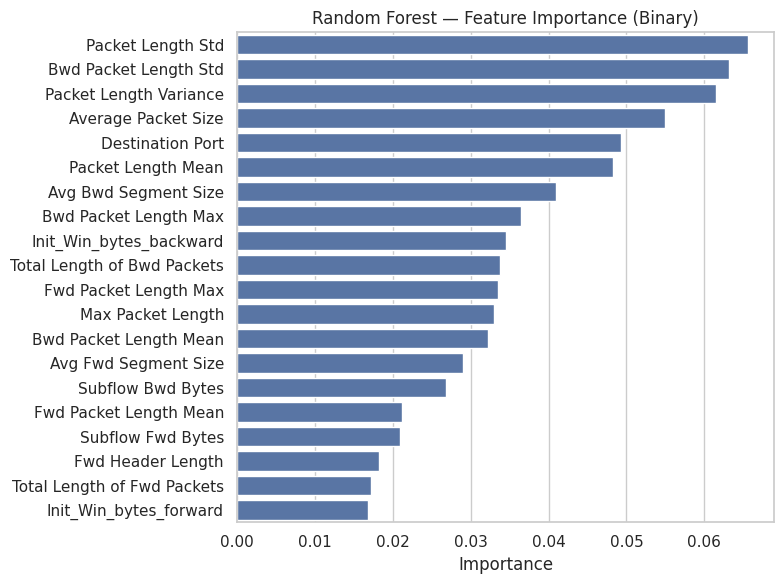

In [10]:
plot_feature_importance(rf, prep.feature_names, top_n=20,
                          title="Random Forest — Feature Importance (Binary)")
plt.savefig("../outputs/figures/07_binary_feature_importance.png", dpi=150)
plt.show()


---
# Part B — Multiclass Classification (attack type)

Now we predict the *specific* attack category (or `BENIGN`). This is the
more operationally useful task: knowing *what kind* of attack is underway
changes the response (block an IP for PortScan vs. trigger a DDoS
mitigation runbook).


In [11]:
prep_mc = split_and_scale(df, target="label_multiclass")
print(f"Train: {prep_mc.X_train.shape}, Test: {prep_mc.X_test.shape}")
print(f"\nClass distribution:\n{prep_mc.y_train.value_counts()}")


Train: (2016638, 69), Test: (504160, 69)

Class distribution:
label_multiclass
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1558
Web Attack ï¿½ Brute Force       1176
Web Attack ï¿½ XSS                522
Other                              55
Name: count, dtype: int64


## B.1 — Random Forest (multiclass)

We go straight to Random Forest for multiclass, since it dominated the
binary task and natively supports multiclass + `class_weight="balanced"`.


In [12]:
t0 = time.time()
rf_mc = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, class_weight="balanced",
    random_state=RANDOM_STATE
)
rf_mc.fit(prep_mc.X_train, prep_mc.y_train)
rf_mc_pred = rf_mc.predict(prep_mc.X_test)
rf_mc_time = time.time() - t0

print_classification_report(prep_mc.y_test, rf_mc_pred, labels=prep_mc.label_classes,
                              title="Random Forest — Multiclass")
print(f"Train time: {rf_mc_time:.1f}s")


=== Random Forest — Multiclass ===
                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    419012
                       Bot      0.373     0.990     0.541       390
                      DDoS      1.000     1.000     1.000     25603
             DoS GoldenEye      0.991     0.996     0.993      2057
                  DoS Hulk      0.996     1.000     0.998     34569
          DoS Slowhttptest      0.988     0.996     0.992      1046
             DoS slowloris      0.992     0.990     0.991      1077
               FTP-Patator      0.999     0.999     0.999      1186
                     Other      0.889     0.615     0.727        13
                  PortScan      0.989     0.999     0.994     18139
               SSH-Patator      0.998     1.000     0.999       644
Web Attack ï¿½ Brute Force      0.763     0.701     0.730       294
        Web Attack ï¿½ XSS      0.414     0.485     0.447       130

           

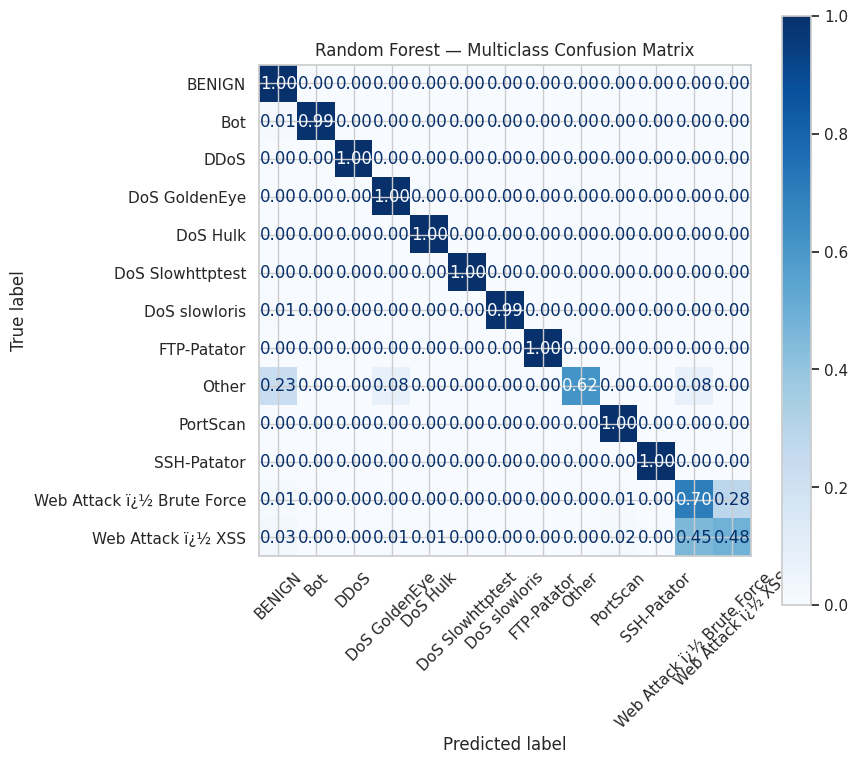

In [13]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_confusion_matrix(prep_mc.y_test, rf_mc_pred, labels=prep_mc.label_classes,
                       title="Random Forest — Multiclass Confusion Matrix",
                       normalize="true", ax=ax)
plt.savefig("../outputs/figures/08_multiclass_confusion_matrix.png", dpi=150)
plt.show()


## B.2 — XGBoost (multiclass)


In [14]:
le_mc = LabelEncoder()
y_train_mc_enc = le_mc.fit_transform(prep_mc.y_train)
y_test_mc_enc = le_mc.transform(prep_mc.y_test)

# sample weights for imbalance (XGBoost has no class_weight param)
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight("balanced", y_train_mc_enc)

t0 = time.time()
xgb_mc = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    objective="multi:softmax", num_class=len(le_mc.classes_),
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_mc.fit(prep_mc.X_train, y_train_mc_enc, sample_weight=sample_weight)
xgb_mc_pred = xgb_mc.predict(prep_mc.X_test)
xgb_mc_time = time.time() - t0

print_classification_report(y_test_mc_enc, xgb_mc_pred,
                              labels=list(range(len(le_mc.classes_))),
                              title="XGBoost — Multiclass")
print("Label mapping:", dict(enumerate(le_mc.classes_)))
print(f"Train time: {xgb_mc_time:.1f}s")


=== XGBoost — Multiclass ===
              precision    recall  f1-score   support

           0      1.000     0.999     0.999    419012
           1      0.695     0.995     0.819       390
           2      1.000     1.000     1.000     25603
           3      0.988     1.000     0.993      2057
           4      0.998     0.999     0.999     34569
           5      0.986     0.995     0.990      1046
           6      0.994     0.992     0.993      1077
           7      0.999     0.999     0.999      1186
           8      0.846     0.846     0.846        13
           9      0.989     0.999     0.994     18139
          10      1.000     1.000     1.000       644
          11      0.768     0.799     0.783       294
          12      0.468     0.454     0.461       130

    accuracy                          0.999    504160
   macro avg      0.902     0.929     0.914    504160
weighted avg      0.999     0.999     0.999    504160

Label mapping: {0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 

In [15]:
mc_results = {
    "Random Forest": {
        "accuracy": accuracy_score(prep_mc.y_test, rf_mc_pred),
        "macro_f1": f1_score(prep_mc.y_test, rf_mc_pred, average="macro"),
        "weighted_f1": f1_score(prep_mc.y_test, rf_mc_pred, average="weighted"),
        "train_time_s": rf_mc_time,
    },
    "XGBoost": {
        "accuracy": accuracy_score(y_test_mc_enc, xgb_mc_pred),
        "macro_f1": f1_score(y_test_mc_enc, xgb_mc_pred, average="macro"),
        "weighted_f1": f1_score(y_test_mc_enc, xgb_mc_pred, average="weighted"),
        "train_time_s": xgb_mc_time,
    },
}
summarize_results(mc_results)


,accuracy,macro_f1,weighted_f1,train_time_s
Random Forest,0.997527,0.877720,0.997825,190.375330
XGBoost,0.998731,0.913637,0.998762,337.446624


## B.3 — Feature importance (multiclass)


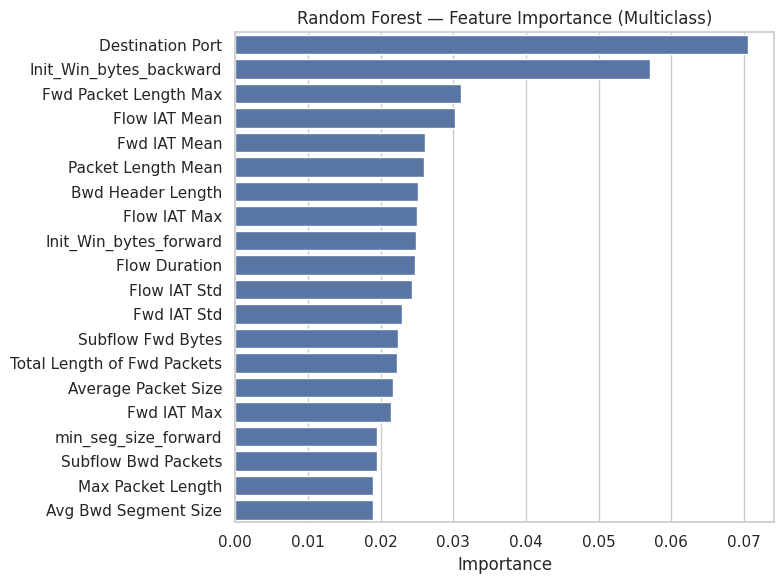

In [16]:
plot_feature_importance(rf_mc, prep_mc.feature_names, top_n=20,
                          title="Random Forest — Feature Importance (Multiclass)")
plt.savefig("../outputs/figures/09_multiclass_feature_importance.png", dpi=150)
plt.show()


---
# Part C — Save the best model

Based on the comparison above, we persist the strongest binary and
multiclass models (plus their scalers/label encoders) for use in the
Streamlit demo.


In [17]:
import os
os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(rf, "../outputs/models/binary_random_forest.joblib")
joblib.dump(prep.scaler, "../outputs/models/binary_scaler.joblib")

joblib.dump(rf_mc, "../outputs/models/multiclass_random_forest.joblib")
joblib.dump(prep_mc.scaler, "../outputs/models/multiclass_scaler.joblib")
joblib.dump(le_mc, "../outputs/models/multiclass_label_encoder.joblib")

with open("../outputs/models/feature_names.txt", "w") as f:
    f.write("\n".join(prep.feature_names))

print("Models saved to outputs/models/")


Models saved to outputs/models/


---
## Summary & Discussion

**Findings to fill in once run on the real dataset:**
- Compare binary vs multiclass performance — which attack types are hardest
  to distinguish from BENIGN or from each other? (Check the multiclass
  confusion matrix for off-diagonal mass — Web Attack subtypes and
  Infiltration are typically the hardest in CICIDS2017.)
- Discuss the top features from the importance plots — do they make
  intuitive sense given how each attack type behaves at the network level?
- Note the train-time / accuracy tradeoff between Random Forest and
  XGBoost — was the extra complexity of XGBoost worth it here?
- Caveats: CICIDS2017 traffic was generated in a controlled testbed, so
  absolute performance numbers won't transfer directly to production
  networks, but the *methodology* (imbalance handling, feature importance,
  multiclass evaluation) generalizes.
